In [1]:
print("Hello")

Hello


In [2]:
import pandas as pd

In [3]:
df = pd.read_excel("Online Retail.xlsx")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [10]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [11]:
df = df.dropna(subset=["CustomerID"])

In [12]:
df = df[df["Quantity"] > 0]

In [13]:
df.shape

(397924, 9)

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
id_counts = df.groupby("CustomerID")["InvoiceNo"].nunique()
id_counts.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64

In [16]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (df["InvoiceDate"].max() - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [17]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,91.518322,4.271952,2053.793018
std,100.009747,7.705493,8988.248381
min,0.000000,1.000000,0.000000
25%,17.000000,1.000000,307.245000
50%,50.000000,2.000000,674.450000
75%,141.000000,5.000000,1661.640000
max,373.000000,210.000000,280206.020000


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [19]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

inertia

[9014.230458865342,
 5440.361406317235,
 4093.501546480753,
 3120.8688237570514,
 2472.3852281769296,
 2022.1131303388388,
 1714.8606966840357,
 1465.7113393418144,
 1289.1198044909634]

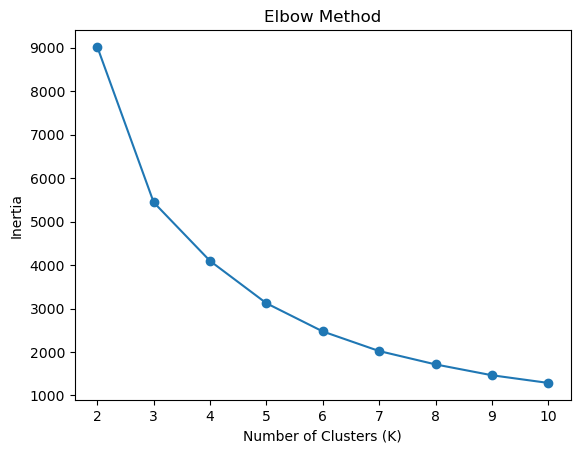

In [20]:
import matplotlib.pyplot as plt

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,325,1,77183.60,0
12347.0,1,7,4310.00,3
12348.0,74,4,1797.24,3
12349.0,18,1,1757.55,3
12350.0,309,1,334.40,1


In [22]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0     211
1    1062
2      13
3    3053
Name: count, dtype: int64

In [23]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,14.672986,22.047393,12453.225924
1,247.564030,1.551789,478.107581
2,6.384615,82.692308,127338.313846
3,42.910580,3.655748,1349.698298


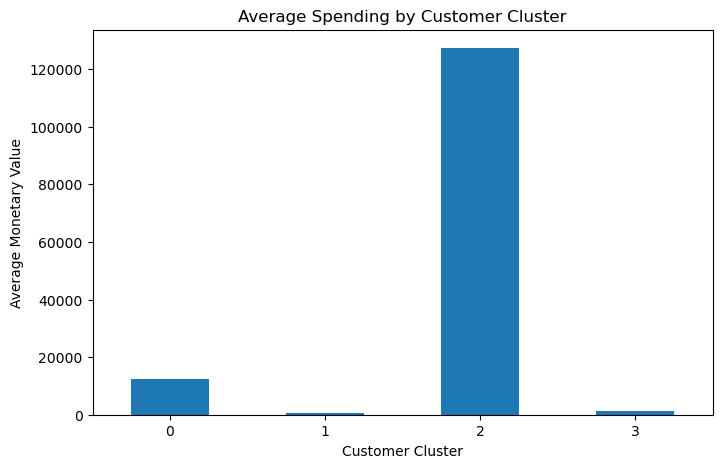

In [24]:
plt.figure(figsize=(8, 5))
cluster_profile["Monetary"].plot(kind="bar")
plt.xlabel("Customer Cluster")
plt.ylabel("Average Monetary Value")
plt.title("Average Spending by Customer Cluster")
plt.xticks(rotation=0)
plt.show()

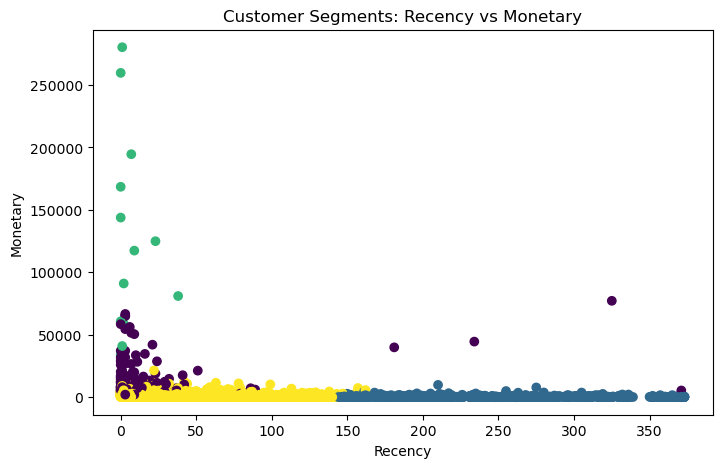

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segments: Recency vs Monetary")
plt.show()

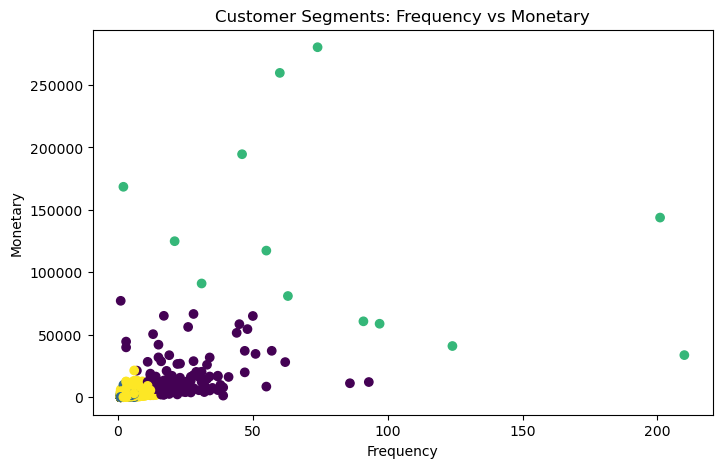

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(rfm["Frequency"], rfm["Monetary"], c=rfm["Cluster"])
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments: Frequency vs Monetary")
plt.show()

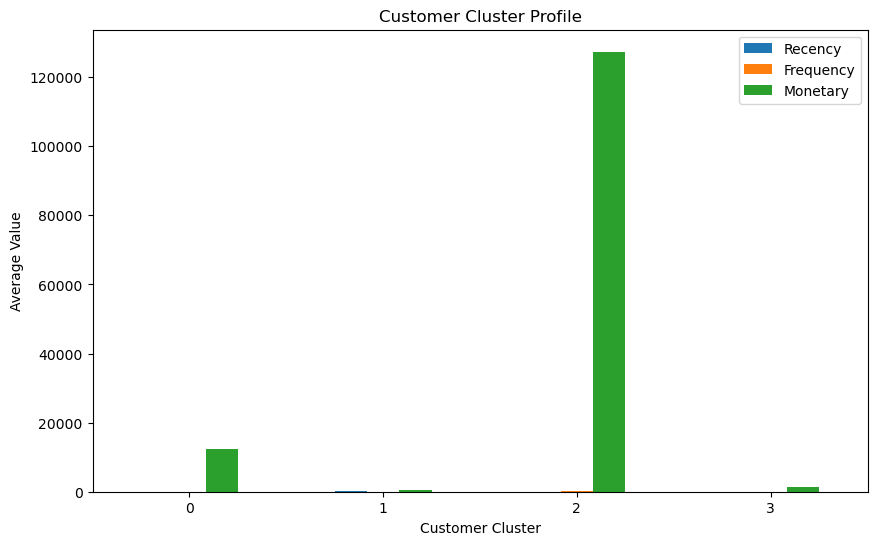

In [27]:
cluster_profile.plot(kind="bar", figsize=(10, 6))
plt.title("Customer Cluster Profile")
plt.xlabel("Customer Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

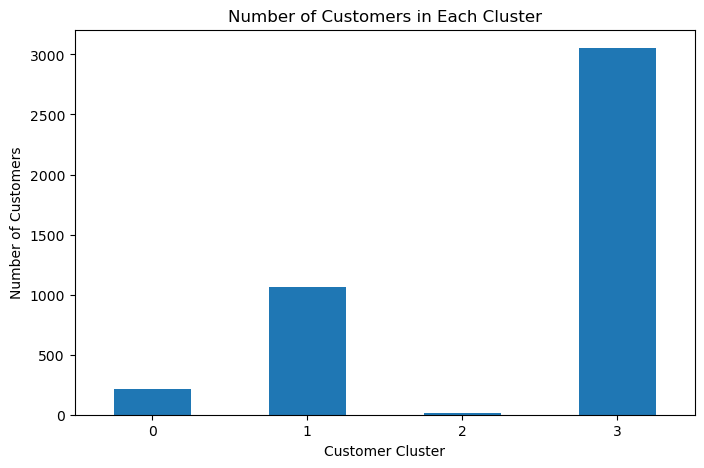

In [28]:
id_counts = rfm["Cluster"].value_counts().sort_index()

id_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")
plt.xticks(rotation=0)
plt.show()

In [29]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,14.672986,22.047393,12453.225924
1,247.564030,1.551789,478.107581
2,6.384615,82.692308,127338.313846
3,42.910580,3.655748,1349.698298


### Cluster Analysis

luster analysis was performed using Recency, Frequency and Monetary values. The K-Means algorithm divided customers into four distinct groups based on their purchasing behaviour.

### Marketing Recommendations

- Target high-value customers with premium offers and loyalty rewards.
- Provide special discounts to frequent customers to encourage repeat purchases.
- Use personalized campaigns for customers who have not purchased recently.
- Create targeted promotions based on the purchasing behaviour of each customer segment.

### Conclusion

Customer segmentation helped identify different groups of customers based on their purchasing behaviour. These segments can be used to create targeted marketing campaigns, personalized offers and customer retention strategies.